In [1]:
import kagglehub
import pandas as pd
import os

dataset_path = kagglehub.dataset_download('rupakroy/online-payments-fraud-detection-dataset')
file_path = os.path.join(dataset_path, 'PS_20174392719_1491204439457_log.csv')
df = pd.read_csv(file_path, encoding='utf-8', engine='python', encoding_errors='ignore')

df

Using Colab cache for faster access to the 'online-payments-fraud-detection-dataset' dataset.


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [2]:
df = df.drop(columns = ['isFlaggedFraud'])
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, average_precision_score, precision_score, recall_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'type_encoded']
X = df[features]
y = df['isFraud']

print(f"Размер выборки: {X.shape}")
print(f"Доля мошенничества: {y.mean()*100:.4f}%")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nОбучающая выборка: {X_train.shape}, аномалий: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Тестовая выборка: {X_test.shape}, аномалий: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер выборки: (6362620, 7)
Доля мошенничества: 0.1291%

Обучающая выборка: (5090096, 7), аномалий: 6570 (0.1291%)
Тестовая выборка: (1272524, 7), аномалий: 1643 (0.1291%)


In [4]:
results = []

lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

f1_lr = f1_score(y_test, y_pred_lr)
pr_auc_lr = average_precision_score(y_test, y_proba_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

results.append({
    'Model': 'Logistic Regression',
    'F1': f1_lr,
    'PR-AUC': pr_auc_lr,
    'Precision': precision_lr,
    'Recall': recall_lr
})

print(f"F1: {f1_lr:.4f}")
print(f"PR-AUC: {pr_auc_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(classification_report(y_test, y_pred_lr))

F1: 0.0594
PR-AUC: 0.5484
Precision: 0.0308
Recall: 0.8734
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.87      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.52      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524



In [5]:
df_sample = df.groupby('isFraud', group_keys=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
)
print(f"Размер подвыборки: {len(df_sample)}")

Размер подвыборки: 1272524


/tmp/ipykernel_6175/1772569090.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('isFraud', group_keys=False).apply(


In [6]:
df_sample['type_encoded'] = le.fit_transform(df_sample['type'])

features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'type_encoded']
X = df_sample[features]
y = df_sample['isFraud']

print(f"Размер выборки: {X.shape}")
print(f"Доля мошенничества: {y.mean()*100:.4f}%")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nОбучающая выборка: {X_train.shape}, аномалий: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Тестовая выборка: {X_test.shape}, аномалий: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер выборки: (1272524, 7)
Доля мошенничества: 0.1291%

Обучающая выборка: (1018019, 7), аномалий: 1314 (0.1291%)
Тестовая выборка: (254505, 7), аномалий: 329 (0.1293%)


In [7]:
rf = RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

f1_rf = f1_score(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

results.append({
    'Model': 'Random Forest',
    'F1': f1_rf,
    'PR-AUC': pr_auc_rf,
    'Precision': precision_rf,
    'Recall': recall_rf
})

print(f"F1: {f1_rf:.4f}")
print(f"PR-AUC: {pr_auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

smote = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"После SMOTE: аномалий {y_train_smote.sum()} ({y_train_smote.mean()*100:.2f}%)")

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

f1_smote = f1_score(y_test, y_pred_smote)
pr_auc_smote = average_precision_score(y_test, y_proba_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)

results.append({
    'Model': 'Random Forest + SMOTE',
    'F1': f1_smote,
    'PR-AUC': pr_auc_smote,
    'Precision': precision_smote,
    'Recall': recall_smote
})

print(f"F1: {f1_smote:.4f}")
print(f"PR-AUC: {pr_auc_smote:.4f}")
print(f"Precision: {precision_smote:.4f}")
print(f"Recall: {recall_smote:.4f}")
print(classification_report(y_test, y_pred_smote))

from xgboost import XGBClassifier

xgb_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_smote.predict(X_test)
y_proba_xgb = xgb_smote.predict_proba(X_test)[:, 1]

f1_xgb = f1_score(y_test, y_pred_xgb)
pr_auc_xgb = average_precision_score(y_test, y_proba_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)

results.append({
    'Model': 'XGBoost + SMOTE',
    'F1': f1_xgb,
    'PR-AUC': pr_auc_xgb,
    'Precision': precision_xgb,
    'Recall': recall_xgb
})

print(f"F1: {f1_xgb:.4f}")
print(f"PR-AUC: {pr_auc_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb))

F1: 0.8567
PR-AUC: 0.9056
Precision: 0.9767
Recall: 0.7629
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    254176
           1       0.98      0.76      0.86       329

    accuracy                           1.00    254505
   macro avg       0.99      0.88      0.93    254505
weighted avg       1.00      1.00      1.00    254505

После SMOTE: аномалий 101670 (9.09%)
F1: 0.7808
PR-AUC: 0.9273
Precision: 0.6810
Recall: 0.9149
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    254176
           1       0.68      0.91      0.78       329

    accuracy                           1.00    254505
   macro avg       0.84      0.96      0.89    254505
weighted avg       1.00      1.00      1.00    254505

F1: 0.6961
PR-AUC: 0.9601
Precision: 0.5392
Recall: 0.9818
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    254176
           1       0.54

In [8]:
def check_overfitting(model, X_train, y_train, X_test, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)
    print(f"{name}: Train F1 = {train_f1:.4f}, Test F1 = {test_f1:.4f}, Разница = {train_f1 - test_f1:.4f}")

check_overfitting(rf, X_train, y_train, X_test, y_test, "Random Forest")
check_overfitting(rf_smote, X_train_smote, y_train_smote, X_test, y_test, "RF + SMOTE")
check_overfitting(xgb_smote, X_train_smote, y_train_smote, X_test, y_test, "XGBoost + SMOTE")

Random Forest: Train F1 = 0.8784, Test F1 = 0.8567, Разница = 0.0217
RF + SMOTE: Train F1 = 1.0000, Test F1 = 0.7808, Разница = 0.2192
XGBoost + SMOTE: Train F1 = 0.9946, Test F1 = 0.6961, Разница = 0.2985


In [9]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier

lgb = LGBMClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)
y_proba_lgb = lgb.predict_proba(X_test)[:, 1]

f1_lgb = f1_score(y_test, y_pred_lgb)
pr_auc_lgb = average_precision_score(y_test, y_proba_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)

results.append({
    'Model': 'LightGBM',
    'F1': f1_lgb,
    'PR-AUC': pr_auc_lgb,
    'Precision': precision_lgb,
    'Recall': recall_lgb
})

print(f"F1: {f1_lgb:.4f}")
print(f"PR-AUC: {pr_auc_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(classification_report(y_test, y_pred_lgb))

lgb_smote = LGBMClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_smote.fit(X_train_smote, y_train_smote)

y_pred_lgb_smote = lgb_smote.predict(X_test)
y_proba_lgb_smote = lgb_smote.predict_proba(X_test)[:, 1]

f1_lgb_smote = f1_score(y_test, y_pred_lgb_smote)
pr_auc_lgb_smote = average_precision_score(y_test, y_proba_lgb_smote)
precision_lgb_smote = precision_score(y_test, y_pred_lgb_smote)
recall_lgb_smote = recall_score(y_test, y_pred_lgb_smote)

results.append({
    'Model': 'LightGBM + SMOTE',
    'F1': f1_lgb_smote,
    'PR-AUC': pr_auc_lgb_smote,
    'Precision': precision_lgb_smote,
    'Recall': recall_lgb_smote
})

print(f"F1: {f1_lgb_smote:.4f}")
print(f"PR-AUC: {pr_auc_lgb_smote:.4f}")
print(f"Precision: {precision_lgb_smote:.4f}")
print(f"Recall: {recall_lgb_smote:.4f}")
print(classification_report(y_test, y_pred_lgb_smote))

gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

f1_gb = f1_score(y_test, y_pred_gb)
pr_auc_gb = average_precision_score(y_test, y_proba_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)

results.append({
    'Model': 'Gradient Boosting',
    'F1': f1_gb,
    'PR-AUC': pr_auc_gb,
    'Precision': precision_gb,
    'Recall': recall_gb
})

print(f"F1: {f1_gb:.4f}")
print(f"PR-AUC: {pr_auc_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(classification_report(y_test, y_pred_gb))

gb_smote = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_smote.fit(X_train_smote, y_train_smote)

y_pred_gb_smote = gb_smote.predict(X_test)
y_proba_gb_smote = gb_smote.predict_proba(X_test)[:, 1]

f1_gb_smote = f1_score(y_test, y_pred_gb_smote)
pr_auc_gb_smote = average_precision_score(y_test, y_proba_gb_smote)
precision_gb_smote = precision_score(y_test, y_pred_gb_smote)
recall_gb_smote = recall_score(y_test, y_pred_gb_smote)

results.append({
    'Model': 'Gradient Boosting + SMOTE',
    'F1': f1_gb_smote,
    'PR-AUC': pr_auc_gb_smote,
    'Precision': precision_gb_smote,
    'Recall': recall_gb_smote
})

print(f"F1: {f1_gb_smote:.4f}")
print(f"PR-AUC: {pr_auc_gb_smote:.4f}")
print(f"Precision: {precision_gb_smote:.4f}")
print(f"Recall: {recall_gb_smote:.4f}")
print(classification_report(y_test, y_pred_gb_smote))

results_df = pd.DataFrame(results)
print(results_df.sort_values('F1', ascending=False).to_string(index=False))

F1: 0.5016
PR-AUC: 0.9541
Precision: 0.3368
Recall: 0.9818
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    254176
           1       0.34      0.98      0.50       329

    accuracy                           1.00    254505
   macro avg       0.67      0.99      0.75    254505
weighted avg       1.00      1.00      1.00    254505

F1: 0.6329
PR-AUC: 0.9592
Precision: 0.4656
Recall: 0.9878
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    254176
           1       0.47      0.99      0.63       329

    accuracy                           1.00    254505
   macro avg       0.73      0.99      0.82    254505
weighted avg       1.00      1.00      1.00    254505

F1: 0.3564
PR-AUC: 0.1501
Precision: 0.2446
Recall: 0.6565
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    254176
           1       0.24      0.66      0.36       329

    a

In [10]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                    Model       F1   PR-AUC  Precision   Recall
      Logistic Regression 0.059419 0.548385   0.030756 0.873402
            Random Forest 0.856655 0.905594   0.976654 0.762918
    Random Forest + SMOTE 0.780804 0.927318   0.680995 0.914894
          XGBoost + SMOTE 0.696121 0.960150   0.539232 0.981763
                 LightGBM 0.501553 0.954108   0.336809 0.981763
         LightGBM + SMOTE 0.632911 0.959226   0.465616 0.987842
        Gradient Boosting 0.356436 0.150089   0.244621 0.656535
Gradient Boosting + SMOTE 0.547782 0.939800   0.380783 0.975684


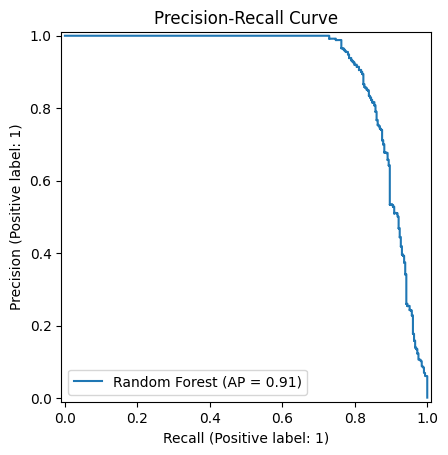

In [12]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

disp = PrecisionRecallDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
disp.ax_.set_title("Precision-Recall Curve")
plt.show()